<a href="https://colab.research.google.com/github/alinas-git/CustomerChurn_Analysis/blob/main/CustumerChurn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive")
df=pd.read_csv('/content/drive/My Drive/Colab Notebooks/CustumerChurn.csv')

rb="#001233"
plt.rcParams["figure.figsize"]=(15,5)
plt.rcParams.update({
    "grid.color":"lightgrey",
    "grid.linestyle":"--",
    "grid.linewidth":1.5,
    "grid.alpha":0.5,
    "axes.grid":True,
    "axes.titleweight":"bold",
    "axes.labelweight":"semibold",
    "axes.titlesize":16,
    "axes.labelsize":12,
    "text.color": rb,
    "axes.labelcolor":rb,
    "axes.titlecolor":rb,
    'axes.axisbelow': True


})


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data understanding and cleaning:

In [198]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128.0,Yes,YES,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107.0,Yes,YES,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137.0,Yes,NO,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84.0,No,NO,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75.0,No,NO,0.0,3,166.7,113,41.0,7.42,10.1


In [199]:
print("Number of Null values by columns:\n")
print(df.isnull().sum())
print("\n\nNumber of duplicate rows:",df.duplicated().sum())

Number of Null values by columns:

Churn               0
AccountWeeks       12
ContractRenewal     0
DataPlan            8
DataUsage           0
CustServCalls       0
DayMins             0
DayCalls            0
MonthlyCharge       3
OverageFee          0
RoamMins            0
dtype: int64


Number of duplicate rows: 0


In [200]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3321 non-null   float64
 2   ContractRenewal  3333 non-null   object 
 3   DataPlan         3325 non-null   object 
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   object 
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3330 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 286.6+ KB


In [201]:
print(df["CustServCalls"].unique())
print(df["ContractRenewal"].unique())
print(df["DataPlan"].unique())

['1' '0' '2' '3' '4' '5' '0 calls' '1 calls' '3 calls' '2 calls' '4 calls'
 '7' '9' '6' '6 calls' '5 calls' '8 calls' '8']
['Yes' 'No']
['YES' 'NO' nan]


In [202]:
df.describe()

,Churn,AccountWeeks,DataUsage,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3321.000000,3333.000000,3333.000000,3333.000000,3330.000000,3333.000000,3333.000000
mean,0.144914,101.129780,0.816475,179.775098,100.435644,56.301471,10.051488,10.237294
std,0.352067,39.824408,1.272668,54.467389,20.069084,16.430939,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,0.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,0.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.780000,216.400000,114.000000,66.175000,11.770000,12.100000
max,1.000000,243.000000,5.400000,350.800000,165.000000,111.300000,18.190000,20.000000


# Feature Engineering:

In [203]:
df=df.dropna(subset=["MonthlyCharge"])

In [204]:
df["DataPlan"]=df.apply(lambda row:"YES"
  if pd.isna(row["DataPlan"]) and row['DataUsage']>0
  else ('NO' if pd.isna(row["DataPlan"]) and row["DataUsage"]==0
              else
                row["DataPlan"]),axis=1)

In [205]:
df["AccountWeeks"]=df["AccountWeeks"].fillna(df["AccountWeeks"].mean())

Changing yes & no values into 1s and 0s

In [206]:
df["ContractRenewal"]=df["ContractRenewal"].replace({'No':0,'Yes':1})
df["DataPlan"]=df["DataPlan"].replace({'NO':0,'YES':1})

In [207]:
df['CustServCalls']=df['CustServCalls'].astype(str).str.replace("calls","").astype(int)

Creating tenure Groups

In [208]:
def tenuregroups(x):
  if x<=26:
    return "0-6 mon"
  elif x<=52:
    return "6-12 mon"
  elif x<=104:
    return "1-2 yr"
  elif x<=156:
    return "2-3 yr"
  elif x<=208:
    return "3+ yr"

df["TenureGroups"]=df['AccountWeeks'].apply(tenuregroups)

In [209]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,TenureGroups
0,0,128.0,1,1,2.7,1,265.1,110,89.0,9.87,10.0,2-3 yr
1,0,107.0,1,1,3.7,1,161.6,123,82.0,9.78,13.7,2-3 yr
2,0,137.0,1,0,0.0,0,243.4,114,52.0,6.06,12.2,2-3 yr
3,0,84.0,0,0,0.0,2,299.4,71,57.0,3.10,6.6,1-2 yr
4,0,75.0,0,0,0.0,3,166.7,113,41.0,7.42,10.1,1-2 yr


## **EDA** (Exploratory Data Analysis)

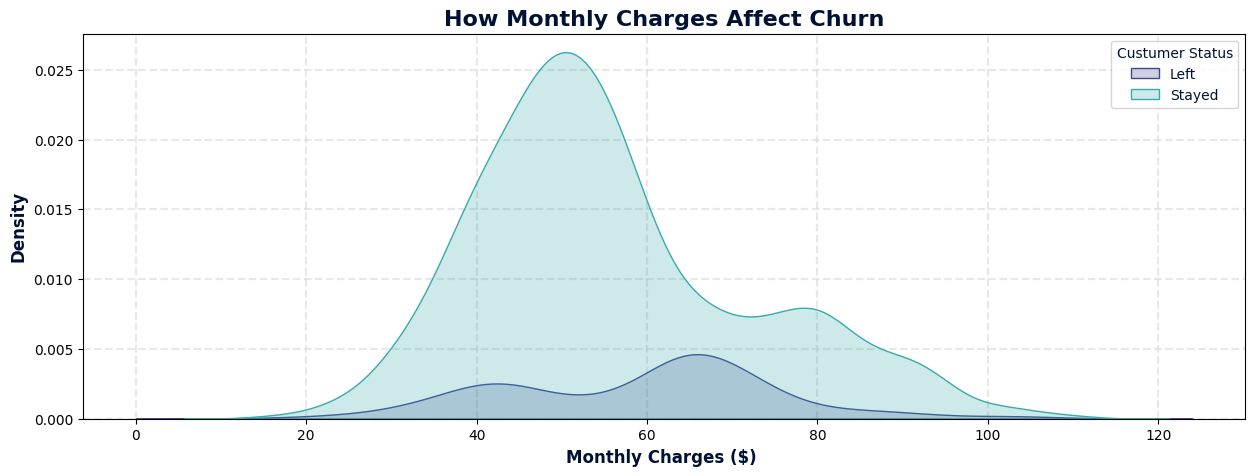

In [210]:
plt.figure(figsize=(15,5))
sns.kdeplot(data=df,x="MonthlyCharge",palette="mako_r",hue="Churn",shade=True)
plt.title("How Monthly Charges Affect Churn")
plt.legend(title="Custumer Status",labels=["Left","Stayed"])
plt.xlabel("Monthly Charges ($) ")
plt.show()

**The Breakdown Analysis:**

* Most loyal customers pay around 50–60 dollars a month. This is the happy zone where they feel they’re getting a good deal.

* Another group stays even at $80 a month, these are the customers who don’t mind paying more for better service.

* The darker blue area (customers who left) gets thicker around 60–80 dollars, this is the breaking point. Higher bills start pushing some customers away.

**Final Conclusion:**

Customers are most stable at 50 dollars per month. Once prices go over 70, churn rises noticeably, shows that higher paying customers are more likely to leave for cheaper alternatives.

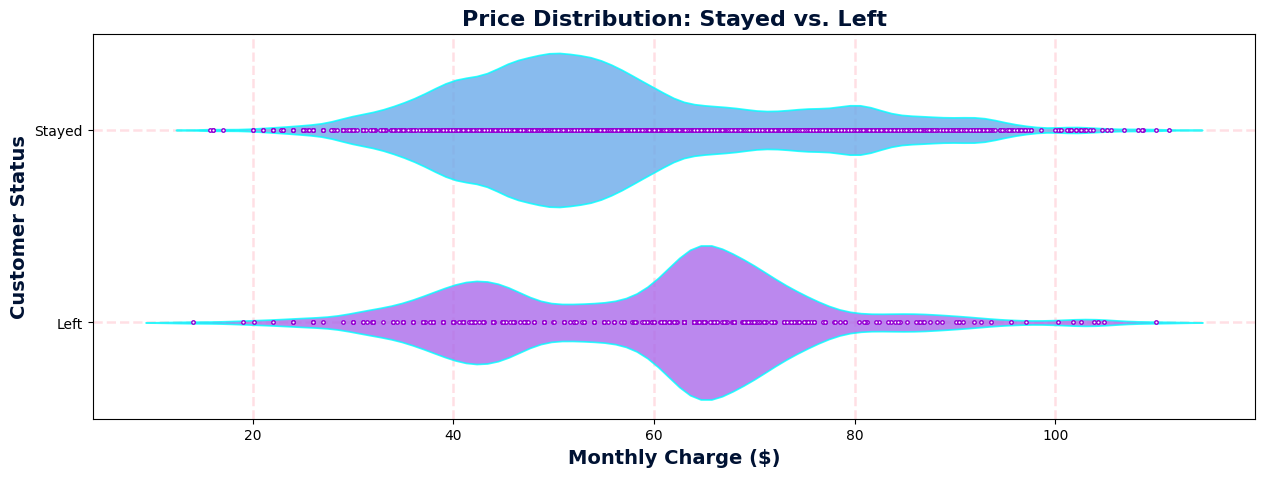

In [211]:
from numpy._core.multiarray import inner
plt.figure(figsize=(15, 5))

sns.violinplot(data=df, y="Churn", x="MonthlyCharge",
               palette="cool",
               inner="point",
               inner_kws={"color":"white",
                          "edgecolor":"Darkviolet"},
               orient="h",
               bw_adjust=0.5,
               alpha=0.8,
               edgecolor="cyan")

plt.gca().set_axisbelow(True),
plt.yticks([0,1],['Stayed', 'Left'])
plt.grid(color="pink",lw=1.8)
plt.title("Price Distribution: Stayed vs. Left", fontsize=16)
plt.xlabel("Monthly Charge ($)", fontsize=14)
plt.ylabel("Customer Status", fontsize=14)
plt.show()

**1. The Bulges:** The thickness of each violin shows where most customers are.

* **The Stayed Bulge**: Most of our Loyal custumber are paying around 40 to 50 dollars. This is our **Sweet Spot** where people are happy and staying.


* **The stayed Bulge**: The bottom one: The big swelling around 60 to 70 dollars. This is our **Danger Zone** it shows that as soon as the pricr hits that area, a massive number of cutumbers are starting to leave.

**2. The Long Tail Stretching:** The long, thin ends of the violins show the full range of prices.

* **The Reach:**: Both violins stretch past $110, this tells us that high paying custumers exist in both groups, but they are rare.

* **The Tapering:**: After around $90, the shape gets very narrow. This shows most customers are not willing to pay more than this

**3. The Horizontal Line:** The bright purple line in the middle of each violin is made up of tiny dots, and each dot is one customer.

* **The Clumping:**: Between $40 and 80 dollars, the dots are very close together, almost like a solid line. This means a lot of customers fall in this range.

* **The Gaps**: As you move toward $100, the dots become more spread out. This shows that only a few customers are paying higher prices.



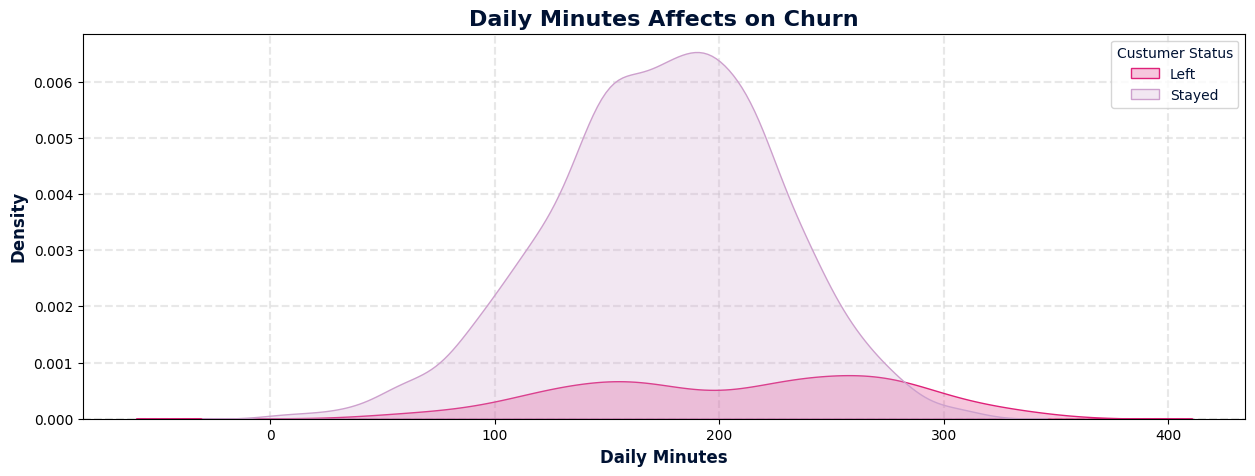

In [212]:
plt.figure(figsize=(15,5))
sns.kdeplot(data=df,x="DayMins",hue="Churn",shade=True,palette="PuRd")
plt.title("Daily Minutes Affects on Churn")
plt.xlabel("Daily Minutes")
plt.legend(title="Custumer Status",labels=["Left","Stayed"])
plt.show()

* **The Danger Zone:**

  After 280 minutes, the orange wave stays higher than the blue wave.

* **The Shift:**

  People who talk more than 250 minutes a day are much more likely to leave the service.

* **The Sweet Spot:**

  That big blue peak around 180 minutes. These are your loyal customers who aren't overusing the service

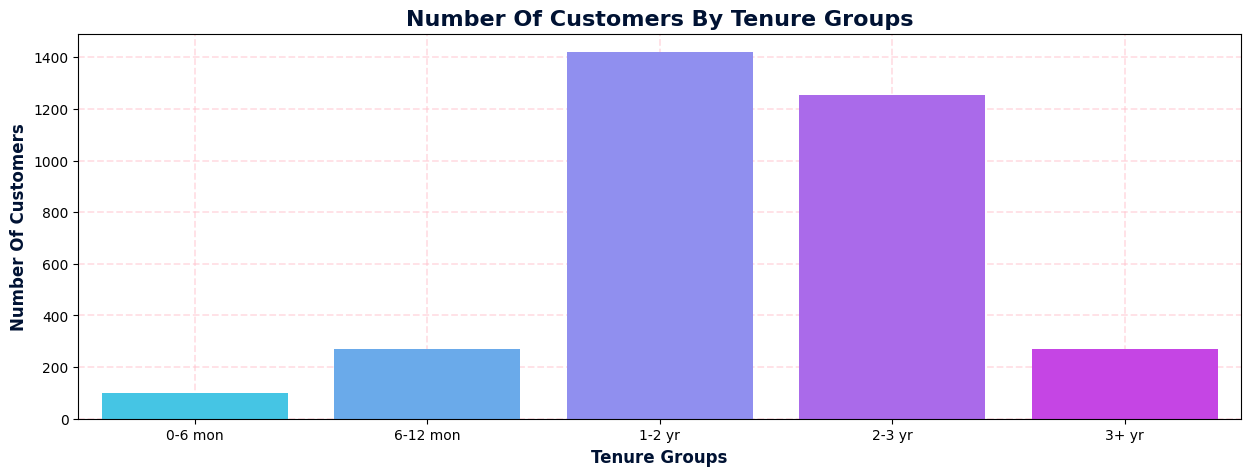

In [213]:

sns.countplot(data=df,x="TenureGroups",
            order=["0-6 mon","6-12 mon","1-2 yr","2-3 yr",'3+ yr'],
            palette="cool")
plt.title("Number Of Customers By Tenure Groups")
plt.xlabel("Tenure Groups")
plt.grid(color="pink",lw=1.3)
plt.ylabel("Number Of Customers")
plt.show()


* **The Big Winners:** Customers in the 1–2 years and 2–3 years groups are comapny's golden customers, they make up the core of your profit right now.

* **The New Guys:** Customers in the 0–6 months and 6–12 months groups are new sign ups. Their smaller numbers show company's attracting quality customers, not just adding random accounts.

* **The Danger Zone:** The 3+ years group is much smaller. This means longterm customers are leaving company's losing our loyal custumers.

**The Insight Conclusion**

Loyalty is strongest between the first and third year of a customer’s journey. After three years, retention drops significantly, to grow the business, introduce longterm rewards to keep these veteran customers before they hit the 36 month mark.

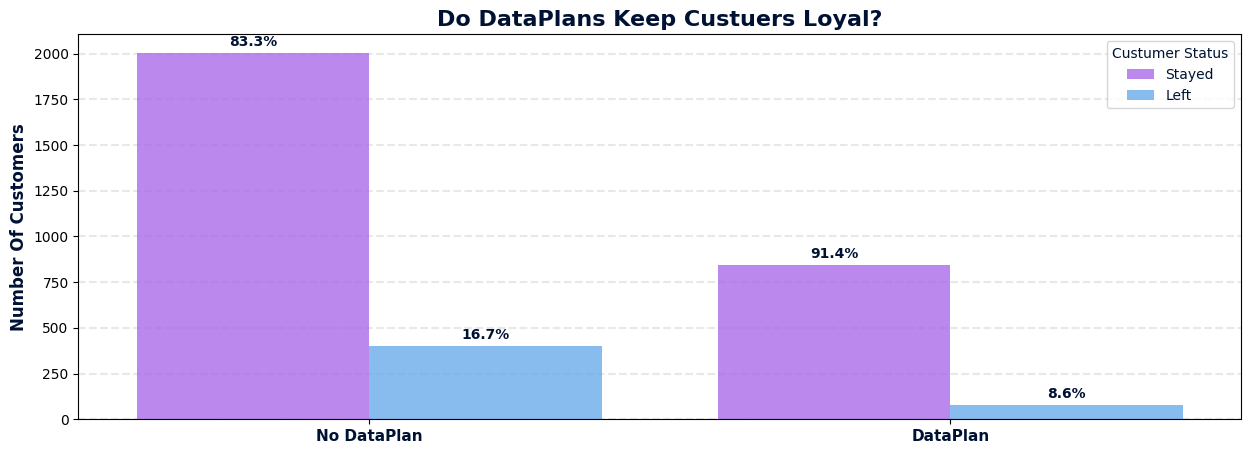

In [214]:
ax=sns.countplot(data=df,x="DataPlan",hue="Churn",palette="cool_r",alpha=0.8)
ax.set_xticklabels(["No DataPlan","DataPlan"],size=11,fontweight="bold",color=rb)
plt.legend(title="Custumer Status",labels=["Stayed",'Left'])

group_counts = df['DataPlan'].value_counts().sort_index().values

for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height > 0:
        total = group_counts[i % 2]
        percentage = (height / total) * 100

        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0,8),
                    textcoords='offset points',
                    fontsize=10,fontweight="semibold")
ax.set_ylabel("Number Of Customers")
ax.set_xlabel("")
plt.title("Do DataPlans Keep Custuers Loyal?")
plt.show()

* **Main insight:** Customers without a data plan leave much more often than those who have one.

* **The difference:** The left bar shows above 16% of customers leaving without
a plan, while the right bar shows only 8.6% leaving with a plan.

* **The Big Risk:** Even though there are more customers without a data plan, they are more than twice as likely (16.7%) to leave compared to (8.6%) customers who have a data plan.

* **Conclusion:** Data plans really help keep customers.
 Getting a customer to sign up for one cuts their chance of leaving by more than half